In [1]:
#Imports

import os
import cv2
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [43]:
# Import functions from local Python files by loading modules from their file paths.
# This avoids invalid "from /path/to/file.py import ..." syntax.

from importlib import util
from pathlib import Path

def load_module_from_path(module_name, file_path):
	file_path = Path(file_path)
	spec = util.spec_from_file_location(module_name, str(file_path))
	module = util.module_from_spec(spec)
	spec.loader.exec_module(module)
	return module

# enhancement.py
_enh = load_module_from_path(
	"enhancement",
	"/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/enhancement.py"
)
erode_image = _enh.erode_image
dilate_image = _enh.dilate_image
histogram_equalization = _enh.histogram_equalization
gradient_enhancement = _enh.gradient_enhancement
sharpen_image = _enh.sharpen_image
clahe_enhancement = _enh.clahe_enhancement
bilateral_filter = _enh.bilateral_filter
unsharp_mask = _enh.unsharp_mask
blackhat_transform = _enh.blackhat_transform
tophat_transform = _enh.tophat_transform
gamma_correction = _enh.gamma_correction
enhance_stone_carving = _enh.enhance_stone_carving
isolate_carving_lines = _enh.isolate_carving_lines
overlay_lines_on_grayscale = _enh.overlay_lines_on_grayscale
overlay_inverted_lines_on_grayscale = _enh.overlay_inverted_lines_on_grayscale
clean_line_mask = _enh.clean_line_mask


# image_segmentation.py
_seg = load_module_from_path(
	"image_segmentation",
	"/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/image_segmentation.py"
)
otsu_thresholding = _seg.otsu_threshold
adaptive_thresholding = _seg.adaptive_threshold


# feature_classification.py
_feat = load_module_from_path(
	"feature_classification",
	"/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/feature_classification.py"
)

edge_detection = _feat.edge_detection
sift_feature_detection = _feat.sift_feature_detection
histogram_analysis = _feat.histogram_analysis

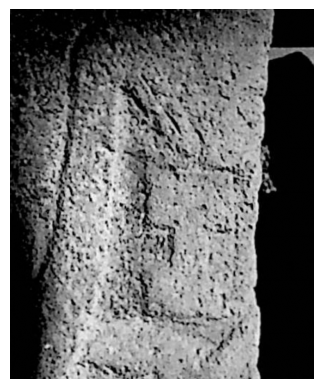

True

In [5]:
#Load image
img = cv2.imread('/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/Misc/Misc1.9.png')

#Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#Display grayscale image
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

#Save as new image
cv2.imwrite('/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/Misc/Misc1.9_gray.png', gray)

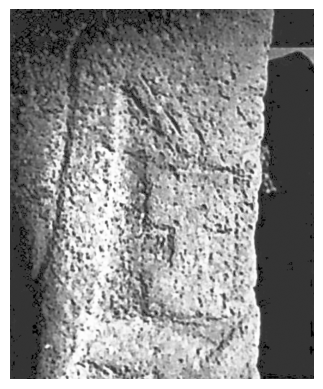

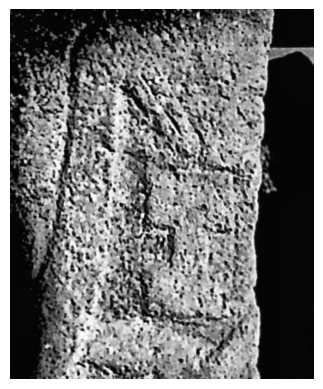

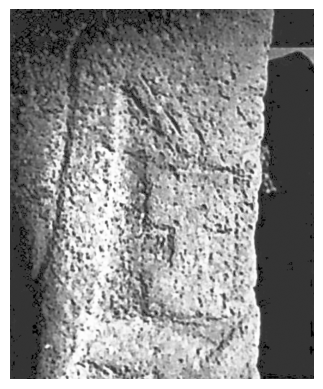

In [31]:
#Enhance contrast using histogram equalization
equalized = histogram_equalization(gray)

#Display equalized image
plt.imshow(equalized, cmap='gray')
plt.axis('off')
plt.show()

#Save equalized image
cv2.imwrite('/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/Misc/Misc1.9_equalized.png', equalized)

#Equalize Again using CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_equalized = clahe.apply(gray)

#Display CLAHE equalized image
plt.imshow(clahe_equalized, cmap='gray')
plt.axis('off')
plt.show()

#Save CLAHE equalized image
cv2.imwrite('/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/Misc/Misc1.9_clahe.png', clahe_equalized)

#Equalize again using histogram equalization function
equalized_again = histogram_equalization(gray)

#Display equalized again image
plt.imshow(equalized_again, cmap='gray')
plt.axis('off')
plt.show()

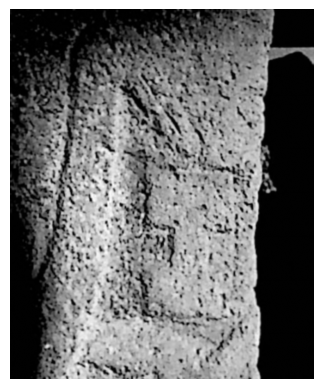

True

In [29]:
#Enhancement using Erosion, Dilation, and Gaussian Blur Filter
# Use explicit structuring element (must be a 2D array) and ensure ksize for GaussianBlur is a tuple
kernel = np.ones((3, 3), dtype=np.uint8)

# Perform erosion then dilation using OpenCV directly to avoid mismatched parameter types
eroded = cv2.erode(gray, kernel, iterations=1)
dilated = cv2.dilate(eroded, kernel, iterations=1)

# Apply Gaussian blur with a proper tuple ksize
blurred = cv2.GaussianBlur(dilated, (5, 5), 0)

#Display enhanced image
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()

#Save enhanced image
cv2.imwrite('/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/Misc/Misc1.9_enhanced.png', blurred)


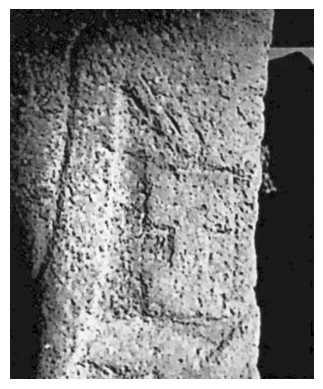

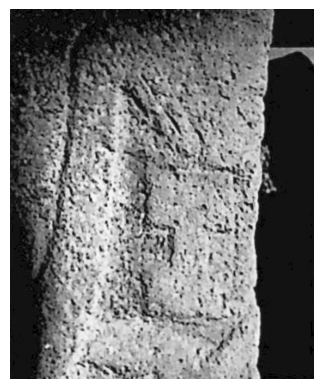

True

In [34]:
#Layer Equalized and Blurred Image to enhance features
layered = cv2.addWeighted(equalized, 0.5, blurred, 0.5, 0)

#Display layered image
plt.imshow(layered, cmap='gray')
plt.axis('off')
plt.show()

#Save layered image
cv2.imwrite('/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/Misc/Misc1.9_layered.png', layered)

#Layer layered image and original grayscale to further enhance features
final_enhanced = cv2.addWeighted(layered, 0.7, gray, 0.3, 0)

#Display final enhanced image
plt.imshow(final_enhanced, cmap='gray')
plt.axis('off')
plt.show()

#Save final enhanced image
cv2.imwrite('/Users/haileyohair/Downloads/Gobekli Tepe Project/Gobekli Tepe/VSCode/Gobekli-Tepe/Gobekli-Tepe/Misc/Misc1.9_final_enhanced.png', final_enhanced)

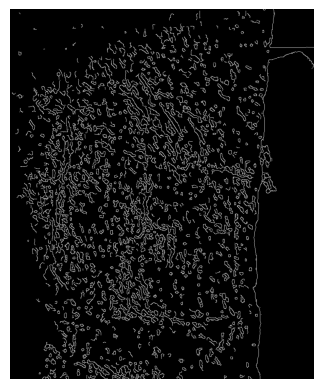

In [35]:
#Edge detection using Canny
edges = cv2.Canny(final_enhanced, 100, 200)

#Display edges
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

In [46]:
#Enhance stone carving
enhanced = enhance_stone_carving(gray)
lines = isolate_carving_lines(enhanced, invert_output=True)  # white lines on black
cleaned_line_mask = clean_line_mask(lines)

# Option A — colour highlight on grayscale (red by default)
result_a = overlay_lines_on_grayscale(gray, clean_line_mask, line_color=(255, 0, 0))  # Red lines

# Option B — inverted lines blended into grayscale
result_b = overlay_inverted_lines_on_grayscale(gray, clean_line_mask)

# Option C — display lines alone (white on black)
result_c = clean_line_mask

#Display result A
plt.imshow(result_a)
plt.axis('off')
plt.show()

#Display result B
plt.imshow(result_b, cmap='gray')
plt.axis('off')
plt.show()

#Display result C
plt.imshow(result_c, cmap='gray')
plt.axis('off')
plt.show()


TypeError: 'numpy.ndarray' object is not callable